In [105]:
import pandas as pd
from database.adatabase import ADatabase
from datetime import datetime, timedelta
from tqdm import tqdm
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor

In [106]:
market = ADatabase("market")

In [107]:
factors = [str(i) for i in range(10)]

In [108]:
market.connect()
prices = market.query("futures",{"ticker":"XRP-PERP-INTX"})
market.disconnect()

In [109]:
prices

,start,low,high,open,close,volume,ticker
0,1708653000,0.5412,0.5412,0.5412,0.5412,2391,XRP-PERP-INTX
1,1708652940,0.5412,0.5413,0.5413,0.5413,10770,XRP-PERP-INTX
2,1708652880,0.5412,0.5413,0.5412,0.5413,3751,XRP-PERP-INTX
3,1708652820,0.5411,0.5412,0.5412,0.5411,13844,XRP-PERP-INTX
4,1708652760,0.5412,0.5412,0.5412,0.5412,4535,XRP-PERP-INTX
...,...,...,...,...,...,...,...
153992,1694829840,0.5017,0.5017,0.5017,0.5017,390,XRP-PERP-INTX
153993,1694829780,0.5014,0.5016,0.5014,0.5016,6032,XRP-PERP-INTX
153994,1694829720,0.5013,0.5013,0.5013,0.5013,260,XRP-PERP-INTX
153995,1694829660,0.5011,0.5011,0.5011,0.5011,1812,XRP-PERP-INTX


In [110]:
prices["date"] = [datetime.fromtimestamp(float(x)) for x in prices["start"]]
prices.sort_values("date",inplace=True)
prices["close"] = [float(x) for x in prices["close"]]
prices["rolling"] = prices["close"].rolling(30).mean()
prices["rolling_mean"] = prices["close"].rolling(window=30).mean()
prices["rolling_std"] = prices["close"].rolling(window=30).std()
for i in range(10):
    prices[str(i)] = prices["close"].shift(i)
prices["y"] = prices["close"].shift(-5)
prices.dropna(inplace=True)
training = prices.iloc[-2000:-1000]
predictions = prices.iloc[-1000:]
model1 = LinearRegression(fit_intercept=True)
model1.fit(training[factors],training["y"])
model2 = CatBoostRegressor(verbose=False)
model2.fit(training[factors],training["y"])
model3 = XGBRegressor(fit_intercept=True)
model3.fit(training[factors],training["y"])
predictions["prediction1"] =  model1.predict(predictions[factors])
predictions["prediction2"] =  model2.predict(predictions[factors])
predictions["prediction3"] =  model3.predict(predictions[factors])
predictions["prediction"] = (predictions["prediction1"] + predictions["prediction2"] + predictions["prediction3"]) / 3
prices = predictions[["date","rolling","rolling_mean","rolling_std","close","prediction"]].copy()

prices["return"] = prices["close"].pct_change()

## moving average
prices["signal"] = prices["rolling"] > prices["close"]

# ai
# prices["signal"] = prices["prediction"] > prices["close"]

# prices["signal"] = prices["rolling"] > prices["close"].rolling(30*2).mean()
prices["signal"] = [1 if x == True else - 1 for x in prices["signal"]]


# Calculate upper and lower Bollinger Bands
# prices["upper_band"] = prices["rolling_mean"] + 2 * prices["rolling_std"]
# prices["lower_band"] = prices["rolling_mean"] - 2 * prices["rolling_std"]
# prices["signal"] = 0  # 0 indicates no signal initially
# prices.loc[prices["close"] < prices["lower_band"], "signal"] = 1
# prices.loc[prices["close"] > prices["upper_band"], "signal"] = -1
# prices["signal"] = prices["signal"].replace(0, method="ffill")
# prices.drop(["rolling_mean", "rolling_std", "upper_band", "lower_band"], axis=1, inplace=True)

C:\Users\eric\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [18:23:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "fit_intercept" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\eric\AppData\Local\Temp\ipykernel_3856\3927268590.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions["prediction1"] =  model1.predict(predictions[factors])
C:\Users\eric\AppData\Local\Temp\ipykernel_3856\3927268590.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [111]:
prices

,date,rolling,rolling_mean,rolling_std,close,prediction,return,signal
1004,2024-02-22 16:26:00,0.544597,0.544597,0.000820,0.5451,0.544513,NaN,-1
1003,2024-02-22 16:27:00,0.544627,0.544627,0.000829,0.5453,0.544631,0.000367,-1
1002,2024-02-22 16:28:00,0.544680,0.544680,0.000832,0.5455,0.544880,0.000367,-1
1001,2024-02-22 16:29:00,0.544707,0.544707,0.000842,0.5454,0.545161,-0.000183,-1
1000,2024-02-22 16:30:00,0.544760,0.544760,0.000846,0.5456,0.545143,0.000367,-1
...,...,...,...,...,...,...,...,...
9,2024-02-23 10:41:00,0.542437,0.542437,0.000574,0.5423,0.542170,-0.000184,1
8,2024-02-23 10:42:00,0.542390,0.542390,0.000532,0.5422,0.542190,-0.000184,1
7,2024-02-23 10:43:00,0.542350,0.542350,0.000506,0.5421,0.542222,-0.000184,1
6,2024-02-23 10:44:00,0.542300,0.542300,0.000493,0.5417,0.542077,-0.000738,1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3343.72it/s]


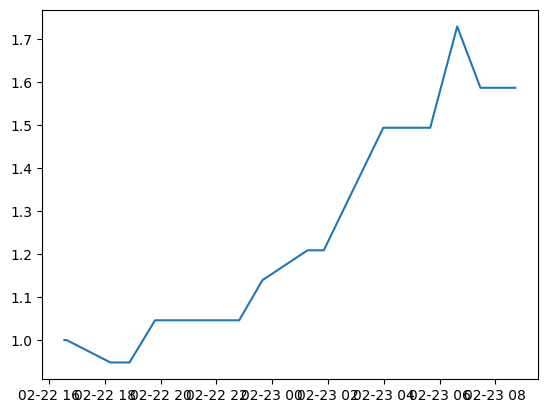

In [112]:
profittake = 0.004
stoploss = 0.001
deadpoint = 0.003
leverage = 15
callback = 0.001
states = []
df = prices.copy()
state = {
"filled":False,
"signal":0,
"buy_price":0,
"sell_price":0
}
for date in tqdm(df["date"]):
    try:
        current_market = df[df["date"]==date] 
        current_price = current_market["close"].item()
        asset_return = current_market["return"].item()
        signal = current_market["signal"].item()
        if state["filled"]==False:
            state["signal"] = signal
            state["buy_price"] = current_price
            state["sell_price"] = current_price
            state["prediction"] = current_market["prediction"].item()
            state["buy_date"] = date
            state["filled"] = True
            state["leverage"] = leverage
        else:
            returns = state["signal"] * (current_price - state["buy_price"]) / state["buy_price"]
            if (asset_return * state["signal"] < -callback and returns > profittake) or returns <-deadpoint:
                state["sell_price"] = current_price
                state["sell_date"] = date
                states.append(state.copy())
                state = {
                    "filled":False,
                    "signal":0,
                    "buy_price":0,
                    "sell_price":0
                }
            elif returns <= -stoploss:
                state["sell_price"] = state["buy_price"]
                state["sell_date"] = date
                states.append(state.copy())
                state = {
                    "filled":False,
                    "signal":0,
                    "buy_price":0,
                    "sell_price":0
                }
    except Exception as e:
        print(str(e))
        continue
trades = pd.DataFrame(states)
trades["return"] = ((trades["sell_price"] - trades["buy_price"]) / trades["buy_price"] * leverage * trades["signal"] + 1)
trades = trades[trades["return"]>0]
trades["cr"] = trades["return"].cumprod()
plt.plot(trades["sell_date"].values,trades["cr"].values)
plt.show()

In [113]:
trades.sort_values("return",ascending=True).head(10)

,filled,signal,buy_price,sell_price,prediction,buy_date,leverage,sell_date,return,cr
31,True,1,0.5455,0.5425,0.545709,2024-02-23 06:39:00,15,2024-02-23 07:28:00,0.917507,1.587233
2,True,-1,0.5474,0.5493,0.547075,2024-02-22 16:39:00,15,2024-02-22 18:12:00,0.947936,0.947936
0,True,-1,0.5451,0.5451,0.544513,2024-02-22 16:26:00,15,2024-02-22 16:33:00,1.000000,1.000000
32,True,1,0.5423,0.5423,0.542938,2024-02-23 07:29:00,15,2024-02-23 08:13:00,1.000000,1.587233
29,True,-1,0.5509,0.5509,0.548693,2024-02-23 05:36:00,15,2024-02-23 05:40:00,1.000000,1.494225
28,True,-1,0.5495,0.5495,0.548789,2024-02-23 05:32:00,15,2024-02-23 05:35:00,1.000000,1.494225
27,True,-1,0.5502,0.5502,0.549260,2024-02-23 05:30:00,15,2024-02-23 05:31:00,1.000000,1.494225
26,True,-1,0.5493,0.5493,0.549215,2024-02-23 05:17:00,15,2024-02-23 05:29:00,1.000000,1.494225
25,True,-1,0.5488,0.5488,0.548051,2024-02-23 04:00:00,15,2024-02-23 05:16:00,1.000000,1.494225
23,True,1,0.5415,0.5415,0.541830,2024-02-23 01:48:00,15,2024-02-23 01:51:00,1.000000,1.208982


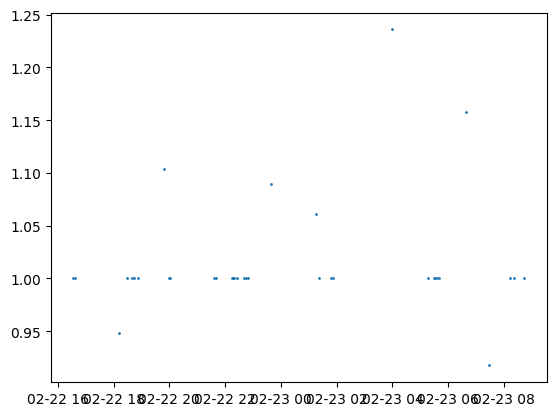

In [114]:
plt.scatter(trades["sell_date"],trades["return"],s=1)
plt.show()